# Benchmark of Explainability Techniques for Neural Networks in Banking Fraud Detection
### TabNet training, evaluation and native attention-based feature importance

**Author:** Andrea Claudia Villanca Rosales

**Master's Thesis (TFM) - Big Data, IA e Ingenieria de Datos, Universidad de Malaga**

This notebook covers the first block of the TFM pipeline:

1. Exploratory Data Analysis (EDA)
2. Preprocessing (imputation, encoding, normalization, class imbalance handling)
3. TabNet model training (PyTorch)
4. Model evaluation (AUC-ROC, Recall, FPR, F1, confusion matrix)
5. Native feature importance analysis (TabNet attention masks)

The dataset used is **Bank Account Fraud (BAF) - Base.csv**, published at NeurIPS 2022.


## 0. Environment Setup

Install and import all required libraries. We use:
- `pandas`/`numpy` for data manipulation
- `matplotlib`/`seaborn` for visualization
- `scikit-learn` for preprocessing, splitting and metrics
- `imbalanced-learn` for SMOTE
- `pytorch-tabnet` for the TabNet architecture
- `torch` as the underlying deep learning framework


In [1]:
# Installation of packages in the environment
# !pip install pytorch-tabnet imbalanced-learn scikit-learn pandas numpy matplotlib seaborn --quiet


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, roc_curve, recall_score, f1_score,
    confusion_matrix, classification_report, precision_score
)

from imblearn.over_sampling import SMOTE

import torch
from pytorch_tabnet.tab_model import TabNetClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.13.0+cpu
CUDA available: False


Aditionally, we use the following libraries to export the model and data to continue the analysis in a second notebook:

In [3]:
from pathlib import Path
import joblib
import os
import json
from sklearn.cluster import KMeans

## 1. Exploratory Data Analysis (EDA)

**Goal:** understand the structure of the BAF dataset before modeling: class distribution,
missing values, feature types and correlations. This step also guides the preprocessing
decisions made in Section 2 (e.g. how to treat the `-1` sentinel values, which columns are
categorical, and how severe the class imbalance is).

**Expected result:** a clear picture of (a) how imbalanced the fraud class is, (b) which
columns encode missing information as `-1` or negatives instead of `NaN`, and (c) which numerical features
are strongly correlated with each other or with the target, (d) columns that should be removed from the analysis.


In [4]:
# Load the dataset 
DATA_PATH = "Base.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head(3)


Shape: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0


In [5]:
# General structure: dtypes, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000000 non-nul

In [6]:
# Basic descriptive statistics for numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


We notice that the `device_fraud_count` column only has zero values in this dataset so it will be removed in Section 2.

### 1.1 Class distribution

The target variable is `fraud_bool` (1 = fraudulent account opening, 0 = legitimate).
The BAF dataset is intentionally built to reflect realistic, highly imbalanced fraud rates
(typically below 1-2% positive class). We visualize this imbalance, since it directly
motivates the resampling / class-weighting strategy in Section 2.


Class counts:
fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Class percentage:
fraud_bool
0    98.897
1     1.103
Name: proportion, dtype: float64


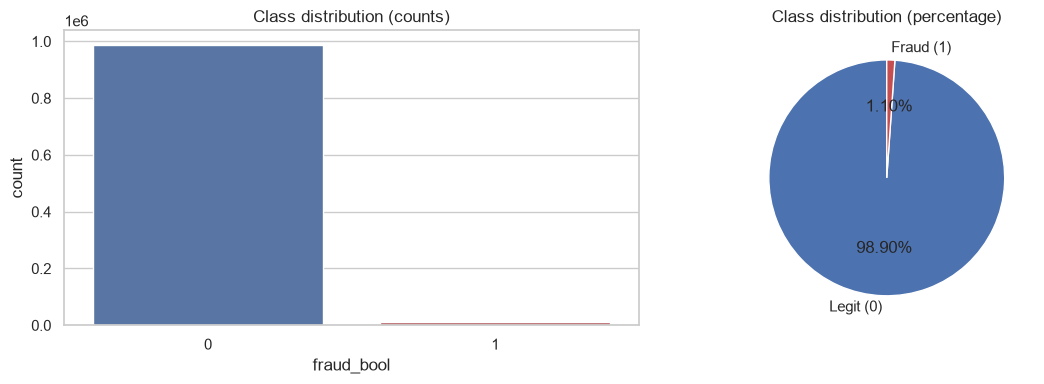

In [7]:
class_counts = df["fraud_bool"].value_counts()
class_pct = df["fraud_bool"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentage:")
print(class_pct.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="fraud_bool", data=df, ax=axes[0], hue="fraud_bool", legend=False, palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Class distribution (counts)")
axes[0].set_xlabel("fraud_bool")

axes[1].pie(class_counts, labels=["Legit (0)", "Fraud (1)"], autopct="%1.2f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Class distribution (percentage)")
plt.tight_layout()
plt.show()

# Expected result: a strongly imbalanced dataset, with the fraud class (1)
# representing a small minority (commonly <2% in BAF variants).


### 1.2 Missing values

Based on the official BAF datasheet (Jesús et al., NeurIPS 2022 Datasets and
Benchmarks track):

- **Exact `-1` sentinel** (only the value `-1` means missing): `prev_address_months_count`,
  `current_address_months_count`, `bank_months_count`, `session_length_in_minutes`,
  `device_distinct_emails_8w`.
- **Any negative value is missing** (not just `-1`): `intended_balcon_amount`, whose valid
  range is `[-16, 114]` and whose negative values are all flagged as missing by the
  datasheet.
- **Negative values that are genuinely valid data, not missing markers:** `credit_risk_score`
  (`[-191, 389]`) and `velocity_6h` (`[-175, 16818]`) both have documented ranges that
  legitimately extend below zero. These must **not** be touched by any missing-value rule.

The exact list of columns and the rule applied to each is implemented in Section 2.1.


In [8]:
# Check for actual NaN values
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
print("Columns with real NaN values:")
print(nan_counts if len(nan_counts) > 0 else "None found")


Columns with real NaN values:
None found


In [9]:
# Check for -1 sentinel values in numerical columns 
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "fraud_bool"]

minus_one_counts = {}
for col in numeric_cols:
    n_minus_one = (df[col] == -1).sum()
    if n_minus_one > 0:
        minus_one_counts[col] = n_minus_one

minus_one_df = pd.DataFrame.from_dict(minus_one_counts, orient="index", columns=["count_-1"])
minus_one_df["pct_-1"] = (minus_one_df["count_-1"] / len(df) * 100).round(2)
minus_one_df = minus_one_df.sort_values("pct_-1", ascending=False)
minus_one_df

# Note: this cell only counts the EXACT value -1. As explained above, intended_balcon_amount
# uses a wider "any negative value" missing-value convention per the official datasheet, so
# its true missing rate is checked separately in the next cell rather than read off this table.
# Also a -1 in credit_risk_score is a valid value.


,count_-1,pct_-1
prev_address_months_count,712920,71.29
bank_months_count,253635,25.36
current_address_months_count,4254,0.43
session_length_in_minutes,2015,0.20
credit_risk_score,488,0.05
device_distinct_emails_8w,359,0.04


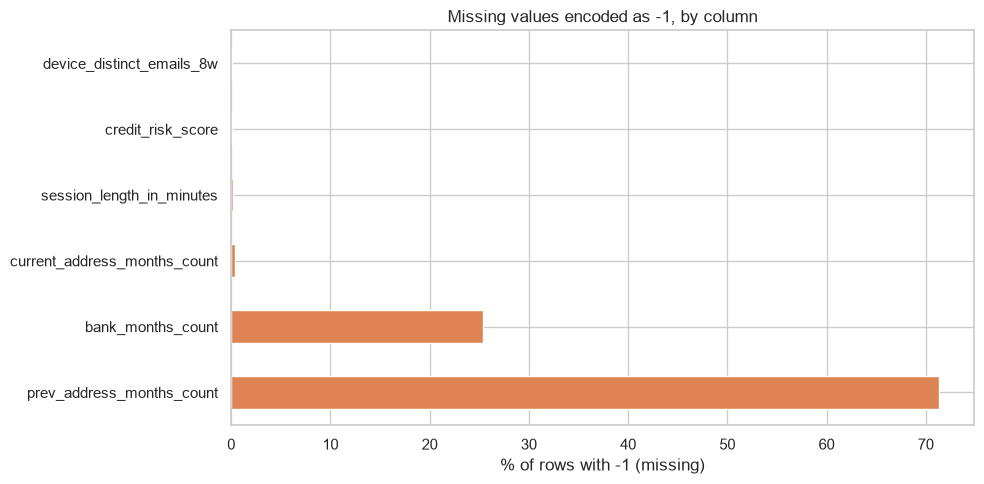

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
minus_one_df["pct_-1"].plot(kind="barh", ax=ax, color="#DD8452")
ax.set_xlabel("% of rows with -1 (missing)")
ax.set_title("Missing values encoded as -1, by column")
plt.tight_layout()
plt.show()


In [11]:
# intended_balcon_amount uses a different missing-value convention: ANY negative value
# (not just -1) is a missing marker, per the official BAF datasheet. We check this
# separately since the generic -1 count above would understate its true missing rate.
n_negative_balcon = (df["intended_balcon_amount"] < 0).sum()
pct_negative_balcon = n_negative_balcon / len(df) * 100
print(f"intended_balcon_amount: {n_negative_balcon} negative values "
      f"({pct_negative_balcon:.2f}% of rows) -> to be treated as missing")


intended_balcon_amount: 742523 negative values (74.25% of rows) -> to be treated as missing


### 1.3 Feature types

We separate columns into categorical and numerical, since this determines the
encoding/normalization strategy applied later.


In [12]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [c for c in df.columns if c not in categorical_cols + ["fraud_bool"]]

print("Categorical columns:", categorical_cols)
print("\nNumber of numerical columns:", len(numerical_cols))
print(numerical_cols)


Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

Number of numerical columns: 26
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


In [13]:
# Cardinality of categorical columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].unique())}")


payment_type: 5 unique values -> ['AA', 'AB', 'AC', 'AD', 'AE']
employment_status: 7 unique values -> ['CA', 'CB', 'CC', 'CD', 'CE', 'CF', 'CG']
housing_status: 7 unique values -> ['BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG']
source: 2 unique values -> ['INTERNET', 'TELEAPP']
device_os: 5 unique values -> ['linux', 'macintosh', 'other', 'windows', 'x11']


### 1.4 Correlation analysis

We compute the Pearson correlation matrix for numerical features and inspect:
1. Correlations among features (to detect redundancy / multicollinearity)
2. Correlation of each feature with the target `fraud_bool` (to get a first signal of
   predictive relevance, complementary to the model-based importance computed later)


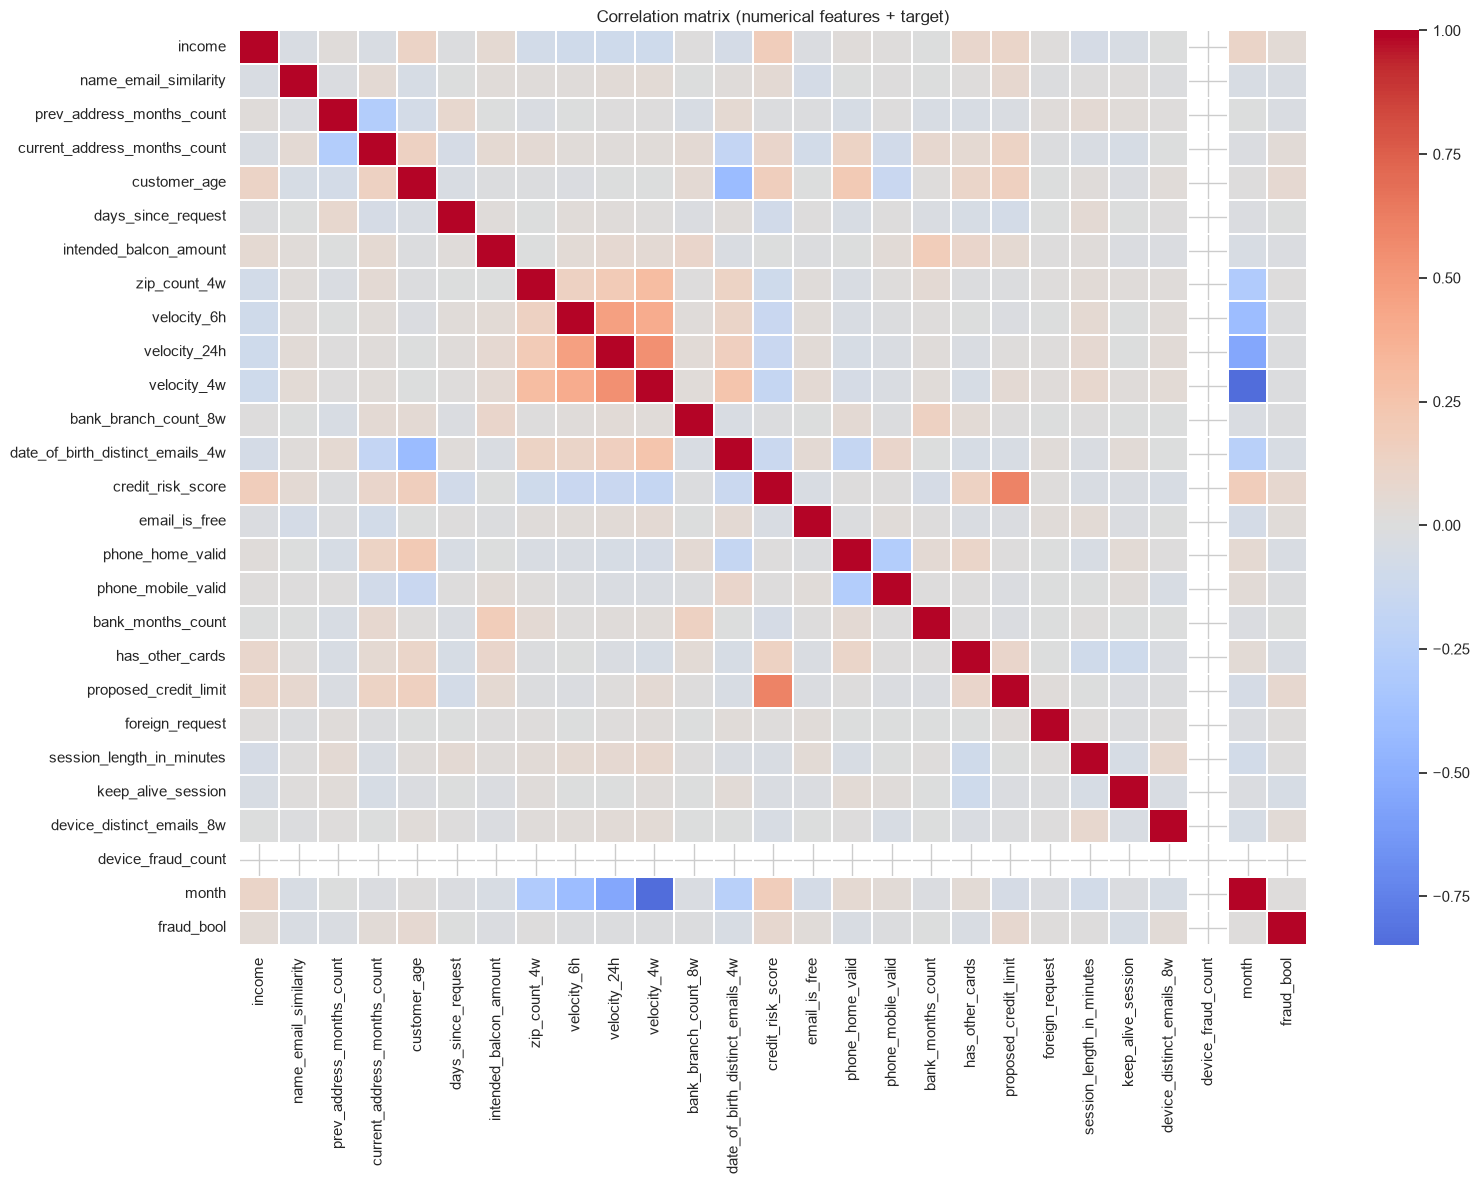

In [14]:
corr_matrix = df[numerical_cols + ["fraud_bool"]].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation matrix (numerical features + target)")
plt.tight_layout()
plt.show()


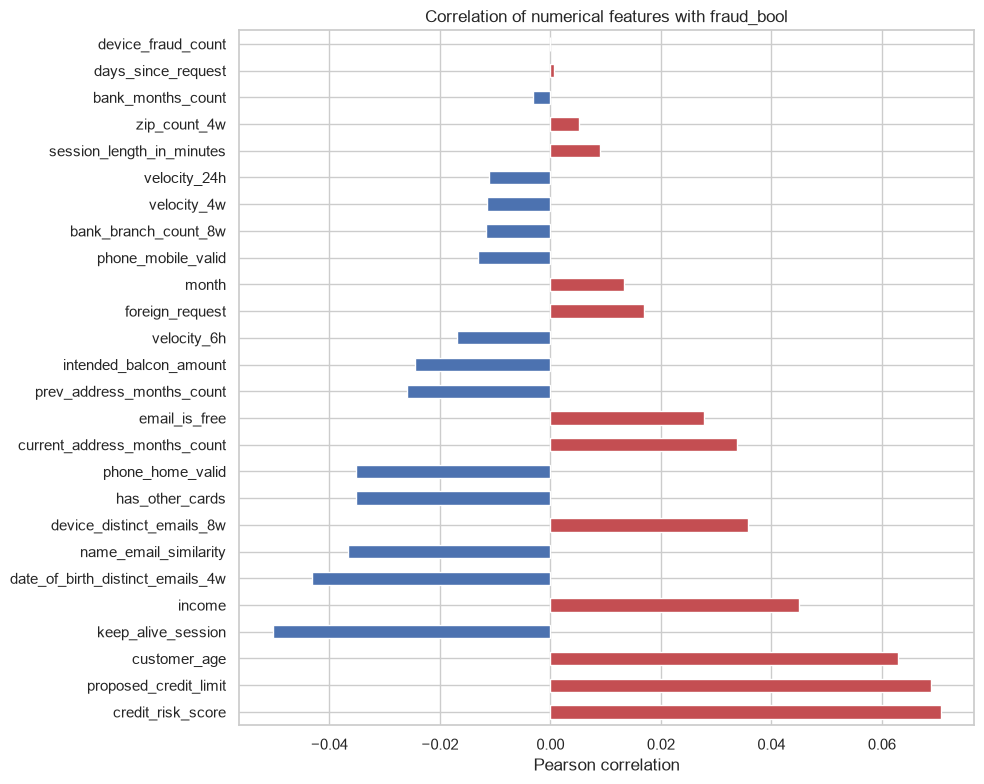

credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
keep_alive_session                 -0.050296
income                              0.045079
date_of_birth_distinct_emails_4w   -0.043224
name_email_similarity              -0.036720
device_distinct_emails_8w           0.035704
has_other_cards                    -0.035156
phone_home_valid                   -0.035128
current_address_months_count        0.033701
email_is_free                       0.027758
prev_address_months_count          -0.026031
intended_balcon_amount             -0.024524
velocity_6h                        -0.016892
foreign_request                     0.016885
month                               0.013250
phone_mobile_valid                 -0.013180
bank_branch_count_8w               -0.011577
velocity_4w                        -0.011536
velocity_24h                       -0.011183
session_length_in_minutes           0.008999
zip_count_

In [15]:
# Correlation of each numerical feature with the target, sorted by absolute value
target_corr = corr_matrix["fraud_bool"].drop("fraud_bool").sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(10, 8))
target_corr.plot(kind="barh", color=["#C44E52" if v > 0 else "#4C72B0" for v in target_corr])
plt.title("Correlation of numerical features with fraud_bool")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

target_corr

# Expected result: correlations with the target are typically weak in this dataset
# (BAF is designed to require non-linear models to separate the classes), which
# motivates the use of a neural network (TabNet) instead of simple linear methods.


In [16]:
# Highly correlated feature pairs (potential redundancy), excluding the diagonal
corr_pairs = corr_matrix.drop("fraud_bool", axis=0).drop("fraud_bool", axis=1).abs()
corr_pairs = corr_pairs.where(np.triu(np.ones(corr_pairs.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().sort_values(ascending=False)

print("Top 10 most correlated feature pairs:")
corr_pairs.head(10)


Top 10 most correlated feature pairs:


velocity_4w        month                               0.848100
credit_risk_score  proposed_credit_limit               0.606141
velocity_24h       month                               0.549919
                   velocity_4w                         0.539115
velocity_6h        velocity_24h                        0.464003
customer_age       date_of_birth_distinct_emails_4w    0.420173
velocity_6h        month                               0.409148
                   velocity_4w                         0.400254
zip_count_4w       velocity_4w                         0.302955
                   month                               0.287203
dtype: float64

In [17]:
# Specific check: velocity_4w vs month
# velocity_4w is an aggregated request-velocity feature computed over a 4-week window,
# so it is expected to be correlated with the (cyclical) month feature.
velocity_month_corr = corr_matrix.loc["velocity_4w", "month"]
print(f"Correlation between velocity_4w and month: {velocity_month_corr:.4f}")

# Note: despite this correlation, velocity_4w is intentionally KEPT as a model feature
# (see Section 2.1b / 2.3). Instead of dropping velocity_4w to resolve the redundancy,
# we exclude "month" itself from the model's input features -- month is used only as the
# temporal split key (Section 2.2), not as a predictor -- which removes the redundancy
# from the model's perspective while preserving velocity_4w's own information content.


Correlation between velocity_4w and month: -0.8481


### 1.5 Distribution of key numerical features by class

A quick visual comparison of a few relevant numerical features, split by class, helps to
spot features with visibly different distributions between fraud and non-fraud cases.


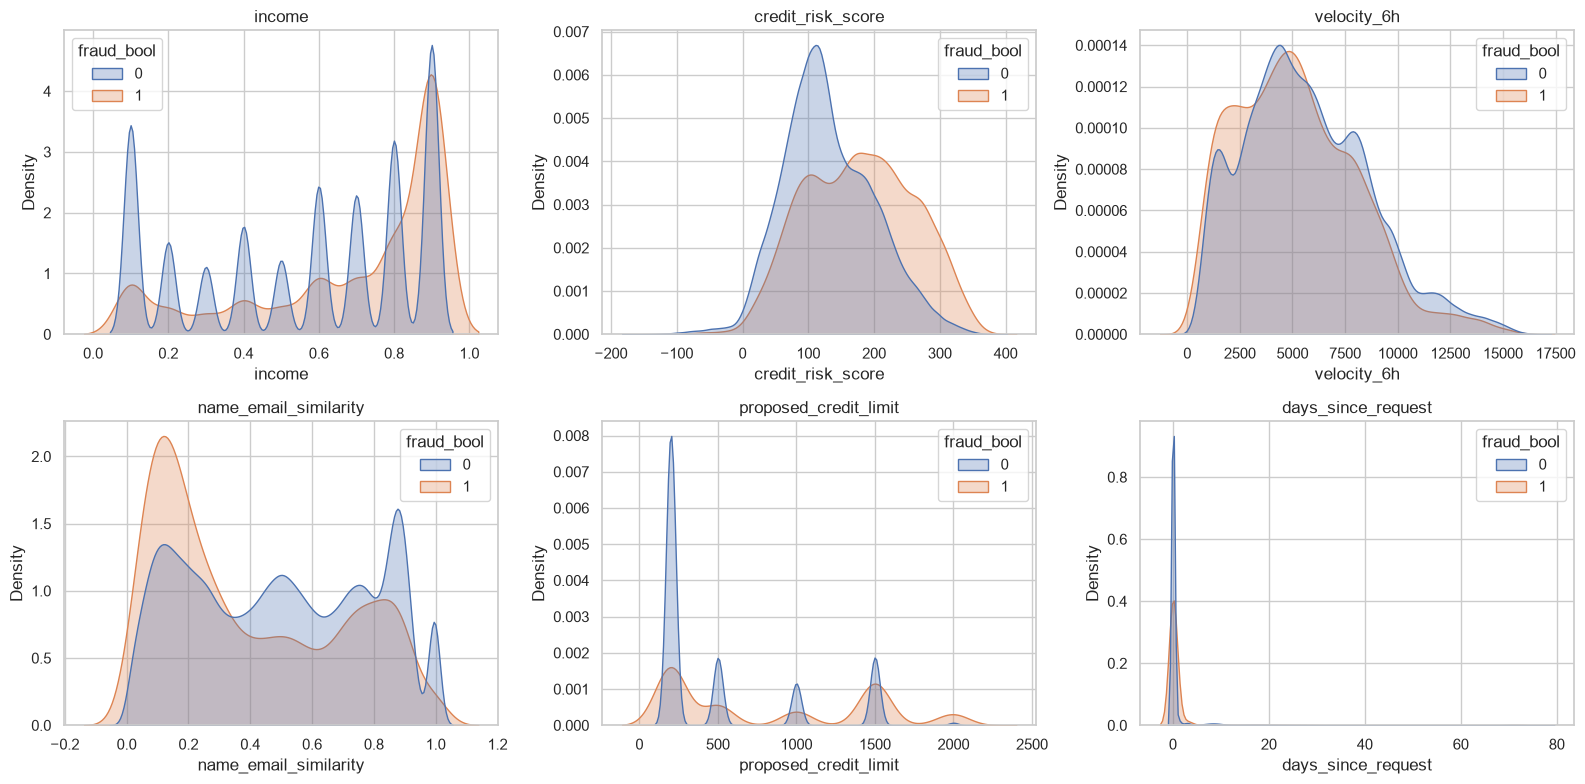

In [18]:
features_to_plot = ["income", "credit_risk_score", "velocity_6h", "name_email_similarity",
                    "proposed_credit_limit", "days_since_request"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    sns.kdeplot(data=df, x=feat, hue="fraud_bool", common_norm=False, ax=axes[i], fill=True, alpha=0.3)
    axes[i].set_title(feat)
plt.tight_layout()
plt.show()


### 1.6 Temporal dynamics: fraud prevalence and volume by month

The original BAF paper (Jesús et al., 2022) reports that both the **fraud prevalence**
(ranging ~0.85%-1.5% across months, higher in later months) and the **application volume**
(ranging ~9.5%-15% of total instances per month) change over the 8-month period covered
by the `month` column. This temporal distribution shift is precisely why the paper
recommends a **temporal** train/test split rather than a random one — a model (and its
explanations) should be evaluated on the most recent, unseen period, not on a random mix
of months. We verify this pattern directly on our data before adopting the temporal split
in Section 2.2.


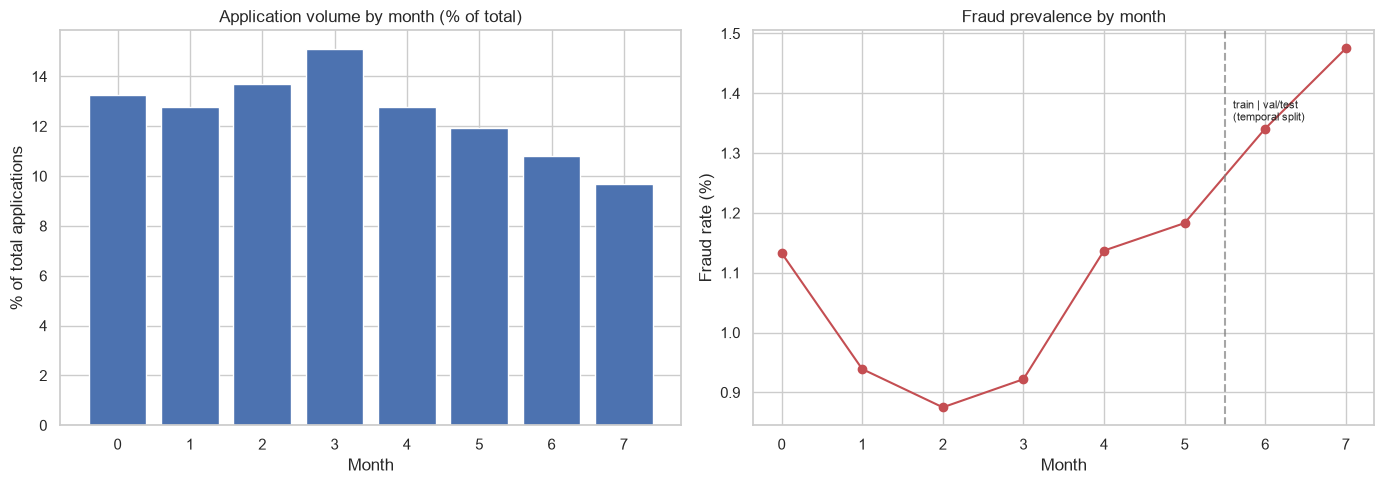

,n_applications,fraud_rate,pct_of_total_applications,fraud_rate_pct
month,,,,
0,132440,0.011326,13.24,1.133
1,127620,0.009387,12.76,0.939
2,136979,0.008746,13.70,0.875
3,150936,0.009222,15.09,0.922
4,127691,0.011371,12.77,1.137
5,119323,0.011825,11.93,1.183
6,108168,0.013405,10.82,1.341
7,96843,0.014746,9.68,1.475


In [19]:
monthly_stats = df.groupby("month").agg(
    n_applications=("fraud_bool", "size"),
    fraud_rate=("fraud_bool", "mean")
)
monthly_stats["pct_of_total_applications"] = (monthly_stats["n_applications"] / len(df) * 100).round(2)
monthly_stats["fraud_rate_pct"] = (monthly_stats["fraud_rate"] * 100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_stats.index, monthly_stats["pct_of_total_applications"], color="#4C72B0")
axes[0].set_title("Application volume by month (% of total)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("% of total applications")

axes[1].plot(monthly_stats.index, monthly_stats["fraud_rate_pct"], marker="o", color="#C44E52")
axes[1].set_title("Fraud prevalence by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].axvline(5.5, linestyle="--", color="gray", alpha=0.7)
axes[1].text(5.6, axes[1].get_ylim()[1] * 0.9, "train | val/test\n(temporal split)", fontsize=8)

plt.tight_layout()
plt.show()

monthly_stats

# Expected result: application volume fluctuating month to month (roughly in the 9-15%
# range reported in the paper), and fraud prevalence trending upward towards the later
# months -- confirming that months 6-7 (used as val/test in Section 2.2) are a harder,
# higher-prevalence period than the training months 0-5.


**EDA summary / takeaways:**
- The target is strongly imbalanced -> resampling or class weighting is required (Section 2).
- Missing values are encoded as `-1` (or, for `intended_balcon_amount`, any negative value)
  -> must be explicitly imputed as missing, per the official BAF datasheet.
- There are both numerical and categorical (`object`) columns -> different preprocessing
  pipelines are needed for each.
- Individual linear correlations with the target are weak -> supports the use of a
  non-linear model such as TabNet, and motivates the later XAI benchmark to understand
  *how* the model actually uses these features.
- Application volume and fraud prevalence both shift across months -> the temporal
  train/val/test split adopted in Section 2.2 (following the original BAF paper) is a more
  realistic evaluation setting than a random split.


## 2. Preprocessing

**Goal:** transform the raw dataset into a clean, model-ready format.

Steps:
1. Replace `-1` and negative sentinel values with real `NaN`, but **only** in the columns confirmed to
   use that convention for missingness.
2. Drop features that are either mostly missing or redundant with another feature.
3. Split the data into train / validation / test sets (stratified, to preserve class ratio).
4. Impute missing values (median for numerical, most-frequent for categorical).
5. Encode categorical columns (One-Hot Encoding).
6. Normalize numerical columns (StandardScaler).
7. Handle class imbalance - two alternatives are implemented: **SMOTE** oversampling on the
   training set, and **class weights**, so both strategies from the anteproyecto are covered.

**Expected result:** `X_train`, `X_val`, `X_test` as clean numerical arrays ready to be fed
into TabNet, plus the corresponding label arrays and the fitted preprocessing pipeline
(needed later to keep feature names aligned for the XAI benchmark).


### 2.1 Replacing sentinel missing-value markers with NaN

Based on the official BAF datasheet (Jesús et al., 2022), two different missing-value
conventions are applied, to two disjoint sets of columns:

**A) Exact `-1` sentinel** — only `-1` means missing:
- `prev_address_months_count`
- `current_address_months_count`
- `bank_months_count`
- `session_length_in_minutes`
- `device_distinct_emails_8w`

**B) Any negative value is missing** (documented range extends below zero specifically to
encode missingness):
- `intended_balcon_amount`

**Explicitly excluded from any missing-value rule:** `credit_risk_score` and `velocity_6h`.
Both have datasheet-documented ranges that legitimately include negative numbers as real,
informative values (not missing markers) — converting them would silently destroy valid
data.


In [20]:
df_clean = df.copy()

# (A) Columns where the missing-value convention is an EXACT -1 sentinel
sentinel_missing_cols = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
    "session_length_in_minutes",
    "device_distinct_emails_8w",
]
for col in sentinel_missing_cols:
    df_clean[col] = df_clean[col].replace(-1, np.nan)

# (B) Columns where the missing-value convention is ANY negative value
# (per the official BAF datasheet, intended_balcon_amount's negative range is
# reserved for missing values, unlike credit_risk_score / velocity_6h, whose negative
# values are valid, real data and are intentionally left untouched)
negative_missing_cols = ["intended_balcon_amount"]
for col in negative_missing_cols:
    df_clean[col] = df_clean[col].where(df_clean[col] >= 0, np.nan)

print("Exact -1 sentinel columns:", sentinel_missing_cols)
print("Any-negative-value sentinel columns:", negative_missing_cols)

# Sanity check: resulting missing-value counts and percentages for all affected columns
missing_summary = df_clean[sentinel_missing_cols + negative_missing_cols].isna().sum().to_frame("n_missing")
missing_summary["pct_missing"] = (missing_summary["n_missing"] / len(df_clean) * 100).round(2)
missing_summary


Exact -1 sentinel columns: ['prev_address_months_count', 'current_address_months_count', 'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w']
Any-negative-value sentinel columns: ['intended_balcon_amount']


,n_missing,pct_missing
prev_address_months_count,712920,71.29
current_address_months_count,4254,0.43
bank_months_count,253635,25.36
session_length_in_minutes,2015,0.20
device_distinct_emails_8w,359,0.04
intended_balcon_amount,742523,74.25


### 2.2 Removing high-null / zero-variance features

Two features are dropped entirely at this stage, before splitting/imputing:

1. **`prev_address_months_count`, `intended_balcon_amount`**: after converting its sentinel values to `NaN` above,
   these columns have a very high percentage of missing values (see the summary table
   above). Imputing such a large fraction of a column would introduce more noise than
   signal, so they are removed rather than imputed.
2. **`device_fraud_count`**: constant (zero variance) in this dataset -- every single row
   has the value `0`. A feature with no variance carries no information and cannot help
   the model, so it is removed.

**`velocity_4w` is intentionally kept** as a model feature. It is correlated with `month`
(see Section 1.4 / the check above), but rather than dropping it we instead exclude
`month` from the model's input features in Section 2.3 -- `month` is used exclusively as
the temporal split key (Section 2.2), not as a predictor, which resolves the redundancy
without discarding `velocity_4w`'s own signal.

**Expected result:** `df_clean` with 3 fewer columns (`prev_address_months_count`,
`device_fraud_count`, `intended_balcon_amount`); `month` and `velocity_4w` both remain in `df_clean`, but `month`
will be excluded specifically at the model-input stage (Section 2.3).


In [21]:
cols_to_drop = ["prev_address_months_count", "device_fraud_count", "intended_balcon_amount"]

print(f"pct missing in prev_address_months_count: "
      f"{df_clean['prev_address_months_count'].isna().mean() * 100:.2f}%")
print(f"pct missing in intended_balcon_amount: "
      f"{df_clean['intended_balcon_amount'].isna().mean() * 100:.2f}%")
print(f"device_fraud_count unique values: {df_clean['device_fraud_count'].unique()}")

df_clean = df_clean.drop(columns=cols_to_drop)

print("\nDropped columns:", cols_to_drop)
print("df_clean shape after removal:", df_clean.shape)


pct missing in prev_address_months_count: 71.29%
pct missing in intended_balcon_amount: 74.25%
device_fraud_count unique values: [0]

Dropped columns: ['prev_address_months_count', 'device_fraud_count', 'intended_balcon_amount']
df_clean shape after removal: (1000000, 29)


### 2.3 Train / Validation / Test split — temporal (BAF official protocol)

We follow the split strategy defined in the original BAF paper (Jesús et al., 2022,
Section 3.1: *"Splitting Strategy"*): the data spans 8 months (`month` column, 0-7), and
the recommended protocol trains on the **first six months** and evaluates on the
**last two**, since this mirrors how fraud models are deployed in practice (trained on
past data, evaluated on the most recent, unseen period) and captures the temporal
distribution shift documented in Section 1.6 below.

We adapt this slightly to also get a validation set for early stopping / threshold tuning
(an extension the paper itself suggests as future work): the first six months (0-5) are
used for training, month 6 for validation, and month 7 — the most recent, held-out
month — for the final test evaluation.

**Expected result:** three chronologically-ordered subsets, each with a different fraud
prevalence (rising over time, as shown in Section 1.6), which is a more realistic and more
demanding evaluation setting than a random split.


In [22]:
TARGET = "fraud_bool"

train_months = list(range(0, 6))   # months 0-5
val_month = 6
test_month = 7

X_train = df_clean[df_clean["month"].isin(train_months)].drop(columns=[TARGET])
y_train = df_clean[df_clean["month"].isin(train_months)][TARGET]

X_val = df_clean[df_clean["month"] == val_month].drop(columns=[TARGET])
y_val = df_clean[df_clean["month"] == val_month][TARGET]

X_test = df_clean[df_clean["month"] == test_month].drop(columns=[TARGET])
y_test = df_clean[df_clean["month"] == test_month][TARGET]

print("Train shape:", X_train.shape, " Fraud rate:", y_train.mean().round(4), " (months 0-5)")
print("Val shape:  ", X_val.shape, " Fraud rate:", y_val.mean().round(4), f" (month {val_month})")
print("Test shape: ", X_test.shape, " Fraud rate:", y_test.mean().round(4), f" (month {test_month})")

# Expected result: fraud rate increasing from train -> val -> test, consistent with the
# paper's observation that fraud prevalence is higher in later months. Unlike a stratified
# random split, this is intentional and realistic -- it is exactly the kind of distribution
# shift a production fraud model has to face.


Train shape: (794989, 28)  Fraud rate: 0.0103  (months 0-5)
Val shape:   (108168, 28)  Fraud rate: 0.0134  (month 6)
Test shape:  (96843, 28)  Fraud rate: 0.0147  (month 7)


### 2.4 Imputation, encoding and normalization pipeline

We build a `ColumnTransformer` with two branches:
- **Numerical branch:** median imputation + standard scaling.
- **Categorical branch:** most-frequent imputation + one-hot encoding.

**`month` is intentionally excluded from the model's input features.** It remains in
`X_train` / `X_val` / `X_test` (and in `df_clean`) because it was needed to build the
temporal split in Section 2.2, but it is not included in `numerical_features` below, so
the `ColumnTransformer` -- and therefore the model -- never sees it as a predictor. This
avoids the model leaning on a raw "which month is this" signal (which trivially separates
train/val/test by construction) and resolves the `velocity_4w` / `month` redundancy noted
in Section 1.4 without having to drop `velocity_4w` itself.

The pipeline is **fit only on the training set** and then applied (transform-only) to
validation and test, to avoid data leakage.


In [23]:
# numerical_cols was computed on the original df (Section 1.3); exclude the columns
# dropped in Section 2.1b, PLUS "month" -- month is only used for the temporal split
# (Section 2.2) and must not be fed into the model as a predictor.
MONTH_COL = "month"
numerical_features = [c for c in numerical_cols if c not in cols_to_drop and c != MONTH_COL]
categorical_features = categorical_cols

print("Numerical features used in the pipeline:", len(numerical_features))
print("Categorical features used in the pipeline:", len(categorical_features))
print(f'"{MONTH_COL}" excluded from model features (split key only):', MONTH_COL not in numerical_features)

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit on train only, transform train/val/test
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Recover feature names for later use (feature importance / XAI)
cat_feature_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_feature_names)

print("Processed train shape:", X_train_proc.shape)
print("Total features after preprocessing:", len(feature_names))


Numerical features used in the pipeline: 22
Categorical features used in the pipeline: 5
"month" excluded from model features (split key only): True
Processed train shape: (794989, 48)
Total features after preprocessing: 48


### 2.5 Handling class imbalance

Two complementary strategies are implemented, matching the anteproyecto:

1. **SMOTE** (Synthetic Minority Over-sampling Technique): generates synthetic fraud
   examples in the training set only, to balance the classes before training.
2. **Class weights**: an alternative that does not alter the training data, but instead
   penalizes misclassification of the minority class more heavily inside the loss function.

We compute both, but use **SMOTE** as the primary strategy for the baseline TabNet model
(Section 3), and keep class weights available as an alternative/ablation.


In [24]:
# Option A: SMOTE oversampling (applied ONLY to the training set)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE: ", np.bincount(y_train_res))

# Expected result: after SMOTE, the training set has an equal (50/50) number of
# fraud and non-fraud samples, while validation and test remain untouched and
# realistic (still imbalanced), so evaluation metrics reflect real-world performance.


Before SMOTE: [786838   8151]
After SMOTE:  [786838 786838]


In [25]:
# Option B: class weights (alternative to SMOTE, kept for comparison/ablation)
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = {int(c): w for c, w in zip(np.unique(y_train), class_weights)}
print("Computed class weights:", class_weight_dict)


Computed class weights: {0: np.float64(0.5051795922413508), 1: np.float64(48.76634768740032)}


## 3. TabNet Model Training

**Goal:** train a `TabNetClassifier` (pytorch-tabnet) to detect fraudulent account
openings, using the preprocessed and SMOTE-balanced training data.

TabNet is chosen because, in addition to strong performance on tabular data, it provides
**native interpretability** through its sequential attention mechanism (attention masks
per decision step), which will be exploited in Section 5 and later compared against
post-hoc XAI methods (SHAP, LIME, Integrated Gradients) in the following notebook.

### 3.1 TabNet architecture - key hyperparameters

- `n_d` (decision layer width) / `n_a` (attention layer width): typically set equal;
  control the capacity of the feature-transformer at each step.
- `n_steps`: number of sequential attention steps (decision steps); more steps allow
  the model to attend to different subsets of features, but increase complexity.
- `gamma`: relaxation parameter controlling how much a feature can be reused across steps.
- `lambda_sparse`: coefficient of the sparsity regularization on the attention masks
  (encourages each step to focus on a small subset of features -> better interpretability).

We tried an earlier run with `lr=2e-2` but it was unstable:
`train_auc`/`valid_auc` oscillated wildly epoch to epoch (occasionally collapsing to
near-random ~0.5) instead of improving steadily, and early stopping ended up keeping
epoch 0 as the best model (`best_epoch=0`) -- i.e. training never improved on its very
first pass. The hyperparameters below lower the learning rate by 10x
and add gradient-norm clipping (`clip_value`) to stabilize training.


In [26]:
tabnet_params = dict(
    n_d=16,                 # width of the decision prediction layer
    n_a=16,                 # width of the attention embedding for each step (usually n_d == n_a)
    n_steps=5,              # number of sequential attention (decision) steps
    gamma=1.5,              # feature reusage relaxation parameter across steps
    lambda_sparse=1e-3,     # sparsity regularization on attention masks (interpretability)
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),   # lowered 10x from 2e-2 -- the higher LR caused unstable,
                                   # oscillating train/valid AUC across epochs (see note above)
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=10, gamma=0.9),
    mask_type="entmax",     # sparse attention masks (entmax) -> cleaner feature importance
    clip_value=2,            # gradient-norm clipping, added to further stabilize training
    seed=RANDOM_STATE,
    verbose=1,
)

clf = TabNetClassifier(**tabnet_params)
print(clf)


TabNetClassifier(n_d=16, n_a=16, n_steps=5, gamma=1.5, cat_idxs=[], cat_dims=[], cat_emb_dim=[], n_independent=2, n_shared=2, epsilon=1e-15, momentum=0.02, lambda_sparse=0.001, seed=42, clip_value=2, verbose=1, optimizer_fn=<class 'torch.optim.adam.Adam'>, optimizer_params={'lr': 0.002}, scheduler_fn=<class 'torch.optim.lr_scheduler.StepLR'>, scheduler_params={'step_size': 10, 'gamma': 0.9}, mask_type='entmax', input_dim=None, output_dim=None, device_name='auto', n_shared_decoder=1, n_indep_decoder=1, grouped_features=[])


The values above (`n_steps=5`, `n_d=n_a=16`) are a reasonable, commonly-used starting point
for tabular datasets of this size. A lightweight grid/manual search could be performed by
varying:

- `n_steps` in `[3, 5, 7]`
- `n_d`/`n_a` in `[8, 16, 24]`
- `lambda_sparse` in `[1e-4, 1e-3, 1e-2]`

and comparing validation AUC. However since it could be time-consuming, and the purpose of this TFM is not to maximize the performance of the model, it could be explored in future analysis.

### 3.2 Training

TabNet's `.fit()` method receives training and evaluation sets directly (no need for a
separate PyTorch training loop), plus early stopping on a chosen validation metric.
We train on the SMOTE-balanced training set and validate on the (untouched, realistic)
validation set, using AUC as the early-stopping criterion.


In [27]:
clf.fit(
    X_train=X_train_res, y_train=y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_val_proc, y_val.values)],
    eval_name=["train", "valid"],
    eval_metric=["auc"],
    max_epochs=100,
    patience=15,           # early stopping patience
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    weights=0,              # weighting already handled via SMOTE; set to 1 to use TabNet's internal balancing instead
    drop_last=False
)


epoch 0  | loss: 0.45585 | train_auc: 0.92417 | valid_auc: 0.81963 |  0:02:54s
epoch 1  | loss: 0.33547 | train_auc: 0.94271 | valid_auc: 0.83575 |  0:05:50s
epoch 2  | loss: 0.30662 | train_auc: 0.94893 | valid_auc: 0.84278 |  0:08:57s
epoch 3  | loss: 0.2919  | train_auc: 0.91926 | valid_auc: 0.77924 |  0:12:03s
epoch 4  | loss: 0.27942 | train_auc: 0.9374  | valid_auc: 0.78763 |  0:15:02s
epoch 5  | loss: 0.27388 | train_auc: 0.94461 | valid_auc: 0.81069 |  0:18:06s
epoch 6  | loss: 0.26429 | train_auc: 0.89266 | valid_auc: 0.78834 |  0:21:36s
epoch 7  | loss: 0.24822 | train_auc: 0.88723 | valid_auc: 0.73196 |  0:27:13s
epoch 8  | loss: 0.23648 | train_auc: 0.96264 | valid_auc: 0.84595 |  0:32:50s
epoch 9  | loss: 0.22997 | train_auc: 0.96706 | valid_auc: 0.84644 |  0:38:32s
epoch 10 | loss: 0.22206 | train_auc: 0.82617 | valid_auc: 0.56404 |  0:44:00s
epoch 11 | loss: 0.21296 | train_auc: 0.97156 | valid_auc: 0.85975 |  0:49:30s
epoch 12 | loss: 0.21366 | train_auc: 0.9686  | vali

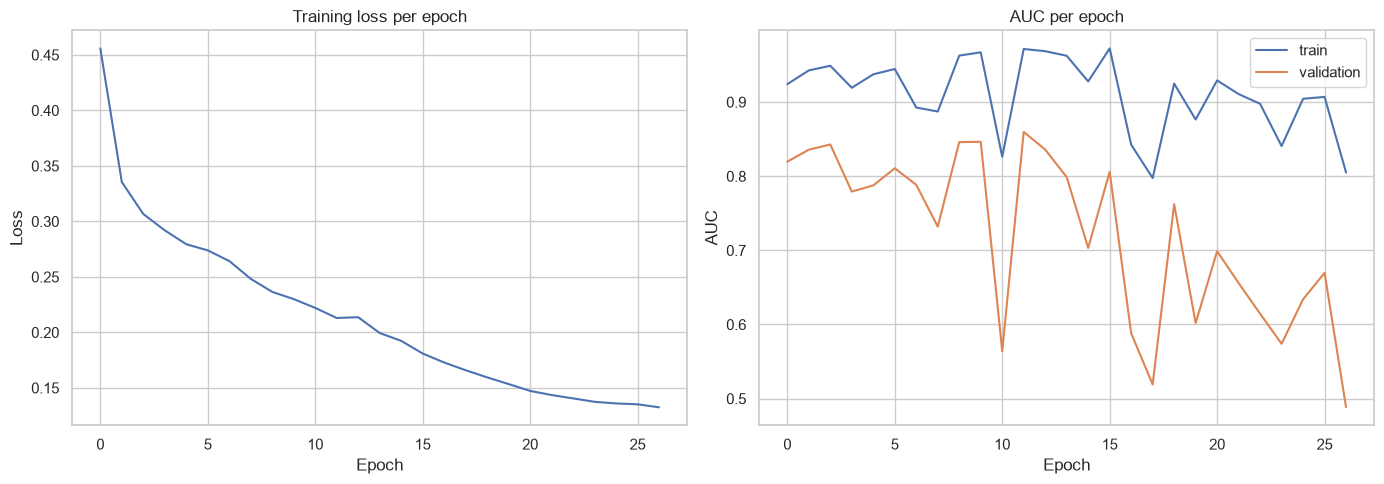

In [28]:
# Training curves: loss and AUC over epochs
history = clf.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["loss"])
axes[0].set_title("Training loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["train_auc"], label="train")
axes[1].plot(history["valid_auc"], label="validation")
axes[1].set_title("AUC per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()
plt.tight_layout()
plt.show()

# Expected result: training loss decreasing steadily, validation AUC increasing and then
# plateauing (early stopping should trigger once validation AUC stops improving).


The residual epoch-to-epoch instability we saw (dips to ~0.49–0.59 valid AUC at various epochs) doesn't actually matter for your final model, since pytorch-tabnet restores the best checkpoint (epoch 11) regardless of what happens afterward — those later bad epochs were discarded automatically.

### 3.3 Diagnosing the train/validation AUC gap: overfitting vs. SMOTE artifact vs. temporal shift

The `train_auc` reported by `fit()` above is computed on the **SMOTE-resampled** training
set (`X_train_res`, `y_train_res` -- a 50/50, partly-synthetic distribution), while
`valid_auc` is computed on the real, imbalanced validation month. Comparing them directly
is misleading, since they're not measured on the same kind of data.

To separate genuine overfitting from this measurement artifact, we recompute AUC on the
**original (non-SMOTE) training distribution** (`X_train_proc`, `y_train`) and compare it
to the validation AUC -- now both are measured on real, un-resampled data.

**Expected result:** if the original-distribution train AUC is still much higher than the
validation AUC, that points to real overfitting and/or a strong temporal distribution
shift between the training and validation months (both plausible here, given Section 1.6).
If it comes out much closer to the validation AUC than the SMOTE-based `train_auc` did,
most of the originally observed gap was a SMOTE-related measurement artifact rather than
the model memorizing the training data.


In [29]:
# Recompute AUC on the ORIGINAL (non-SMOTE) training distribution, for a fair,
# apples-to-apples comparison against the validation AUC (both on real, un-resampled data)
y_train_proba_orig = clf.predict_proba(X_train_proc)[:, 1]
train_auc_original = roc_auc_score(y_train, y_train_proba_orig)

y_val_proba_diag = clf.predict_proba(X_val_proc)[:, 1]
val_auc_clean = roc_auc_score(y_val, y_val_proba_diag)

smote_train_auc = max(history["train_auc"])  # as reported during fit(), on SMOTE-resampled data

print(f"Train AUC (SMOTE-resampled, as reported by fit()): {smote_train_auc:.5f}")
print(f"Train AUC (original, non-SMOTE distribution):       {train_auc_original:.5f}")
print(f"Validation AUC:                                      {val_auc_clean:.5f}")
print()
print(f"Gap vs SMOTE-based train AUC:            {smote_train_auc - val_auc_clean:.5f}")
print(f"Gap vs original-distribution train AUC:  {train_auc_original - val_auc_clean:.5f}")

gap_original = train_auc_original - val_auc_clean
print()
if gap_original > 0.05:
    print("-> Still a sizeable gap on the original (non-SMOTE) distribution: likely a genuine")
    print("   sign of overfitting and/or a strong temporal distribution shift between the")
    print("   training and validation months, rather than purely a SMOTE measurement artifact.")
    print("   Consider: stronger regularization (higher lambda_sparse, fewer n_steps/n_d/n_a),")
    print("   more aggressive early stopping, or re-checking class-weights as an alternative to SMOTE.")
else:
    print("-> Most of the originally observed train/valid AUC gap was a SMOTE-related")
    print("   measurement artifact -- on a fair, real-data comparison, the model generalizes")
    print("   reasonably well from training to validation months.")


Train AUC (SMOTE-resampled, as reported by fit()): 0.97235
Train AUC (original, non-SMOTE distribution):       0.85941
Validation AUC:                                      0.85975

Gap vs SMOTE-based train AUC:            0.11260
Gap vs original-distribution train AUC:  -0.00034

-> Most of the originally observed train/valid AUC gap was a SMOTE-related
   measurement artifact -- on a fair, real-data comparison, the model generalizes
   reasonably well from training to validation months.


## 4. Model Evaluation

**Goal:** evaluate the trained TabNet model on the held-out **test set** (never touched
during training, still reflecting the real, imbalanced class ratio), using the metrics
requested in the anteproyecto:

- **AUC-ROC**: overall ranking quality, robust to class imbalance.
- **Recall (True Positive Rate)**: proportion of actual fraud cases correctly detected -
  the most business-critical metric in fraud detection.
- **False Positive Rate (FPR)**: proportion of legitimate cases incorrectly flagged as
  fraud, important since false positives create friction for genuine customers.
- **F1-score**: harmonic mean of precision and recall.
- **Confusion matrix**: full breakdown of TP/FP/TN/FN.

**Expected result:** a test-set AUC-ROC noticeably above 0.5 (ideally in the 0.80-0.90+
range, consistent with published BAF benchmarks), together with a recall/FPR trade-off
that can be tuned via the classification threshold.


In [30]:
# Predicted probabilities and default (0.5-threshold) predictions on the test set
y_test_proba = clf.predict_proba(X_test_proc)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_test_proba)
recall = recall_score(y_test, y_test_pred)          # True Positive Rate
precision = precision_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
fpr = fp / (fp + tn)

print(f"AUC-ROC:            {auc:.4f}")
print(f"Recall (TPR):        {recall:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"F1-score:            {f1:.4f}")


AUC-ROC:            0.8500
Recall (TPR):        0.5637
False Positive Rate: 0.0833
Precision:           0.0920
F1-score:            0.1582


In [31]:
# Full classification report
print(classification_report(y_test, y_test_pred, target_names=["Legit (0)", "Fraud (1)"]))


              precision    recall  f1-score   support

   Legit (0)       0.99      0.92      0.95     95415
   Fraud (1)       0.09      0.56      0.16      1428

    accuracy                           0.91     96843
   macro avg       0.54      0.74      0.56     96843
weighted avg       0.98      0.91      0.94     96843



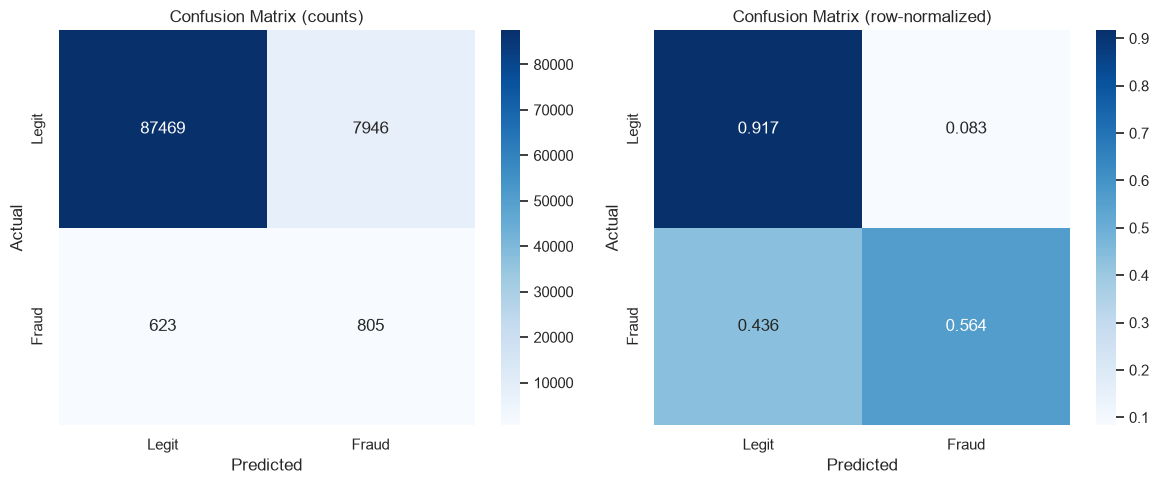

In [32]:
# Confusion matrix (counts and normalized)
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = confusion_matrix(y_test, y_test_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues", ax=axes[1],
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
axes[1].set_title("Confusion Matrix (row-normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()


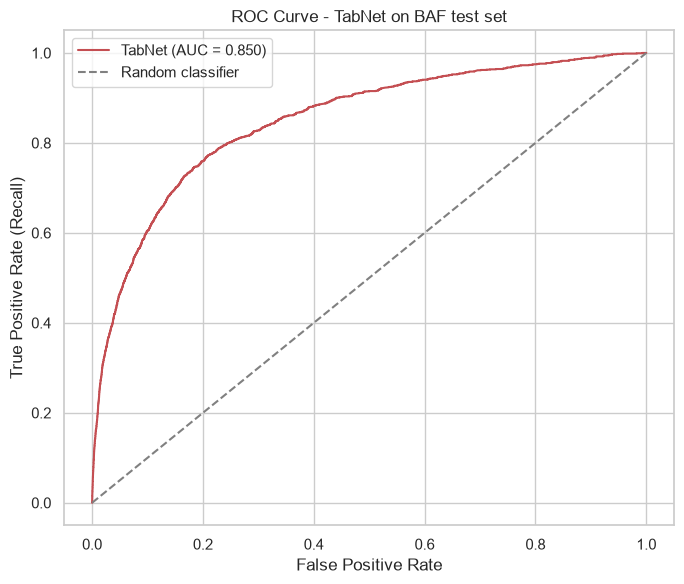

In [33]:
# ROC curve
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_curve, tpr_curve, label=f"TabNet (AUC = {auc:.3f})", color="#C44E52")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - TabNet on BAF test set")
plt.legend()
plt.tight_layout()
plt.show()


**Note on the threshold — official BAF operating point:** the original BAF paper
(Jesús et al., 2022, Section 3.1) defines its standard performance metric as **TPR
(Recall) at a fixed 5% FPR**, arguing this strikes the balance the fraud domain actually
cares about: catching fraud (TPR) while keeping customer friction (FPR) low. We adopt
this as our primary operating point below, alongside a couple of alternative FPR budgets
for context.


In [34]:
target_fprs = [0.01, 0.05, 0.10]  # 0.05 = the operating point used in the original BAF paper
for target_fpr in target_fprs:
    idx = np.argmin(np.abs(fpr_curve - target_fpr))
    marker = "  <-- BAF paper's official operating point" if target_fpr == 0.05 else ""
    print(f"At FPR ~= {fpr_curve[idx]:.3f} -> Recall (TPR) = {tpr_curve[idx]:.3f} "
          f"(threshold = {thresholds[idx]:.3f}){marker}")


At FPR ~= 0.010 -> Recall (TPR) = 0.198 (threshold = 0.928)
At FPR ~= 0.050 -> Recall (TPR) = 0.465 (threshold = 0.673)  <-- BAF paper's official operating point
At FPR ~= 0.100 -> Recall (TPR) = 0.604 (threshold = 0.434)


We could still chase a few more points of recall (with a small hyperparameter sweep trying class weights instead of SMOTE), but given ~3 min/epoch and that this is "good enough to build the XAI benchmark on", this model is ready to move on to Section 5 rather than continuing to tune.

## 5. Native Feature Importance - TabNet Attention Analysis

**Goal:** exploit TabNet's built-in interpretability. Unlike black-box models, TabNet
computes an explicit attention mask at every decision step, indicating which features the
model focuses on for each prediction. This provides two levels of explanation:

1. **Global feature importance**: aggregated attention/importance across the whole model
   (via `clf.feature_importances_`), giving an overall ranking of which features matter most.
2. **Per-step attention masks**: `clf.explain()` returns both an aggregated per-sample
   attribution matrix and the individual masks used at each of the `n_steps` decision steps,
   showing *how the feature focus evolves* across steps for individual predictions.

**Expected result:** a global importance ranking that should highlight features known to be
relevant for account-opening fraud (e.g. `credit_risk_score`, `velocity_*`,
`name_email_similarity`, `device_distinct_emails_8w`), plus visual evidence that different
attention steps focus on different feature subsets - this native explanation will later be
compared against SHAP / LIME / Integrated Gradients in the XAI benchmark notebook.


### 5.1 Global feature importance


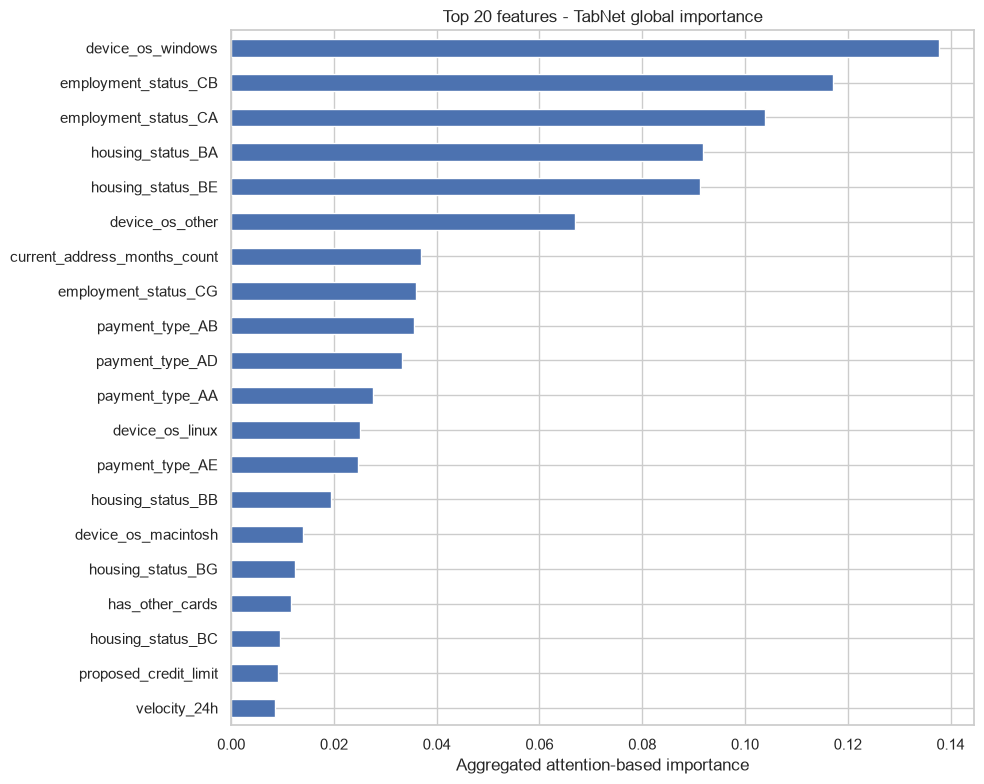

device_os_windows               0.137686
employment_status_CB            0.117128
employment_status_CA            0.103978
housing_status_BA               0.091746
housing_status_BE               0.091219
device_os_other                 0.066895
current_address_months_count    0.037009
employment_status_CG            0.035986
payment_type_AB                 0.035598
payment_type_AD                 0.033288
payment_type_AA                 0.027576
device_os_linux                 0.025110
payment_type_AE                 0.024628
housing_status_BB               0.019336
device_os_macintosh             0.014055
housing_status_BG               0.012373
has_other_cards                 0.011707
housing_status_BC               0.009490
proposed_credit_limit           0.009059
velocity_24h                    0.008603
dtype: float64

In [35]:
global_importances = pd.Series(clf.feature_importances_, index=feature_names)
global_importances = global_importances.sort_values(ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
global_importances.head(top_n).iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title(f"Top {top_n} features - TabNet global importance")
plt.xlabel("Aggregated attention-based importance")
plt.tight_layout()
plt.show()

global_importances.head(top_n)


It is worth noting that no single feature accounts for more than 20% of the total feature importance. This indicates that the model does not rely heavily on any individual predictor; instead, its performance is driven by the combined contribution of multiple features. Such a distribution of importance suggests a balanced feature set and reduces the risk of the model being overly dependent on a single variable.

### 5.2 Per-step attention masks

`clf.explain()` returns:
- `explain_matrix`: an aggregated (n_samples x n_features) attribution matrix
  (sum of masks across steps, weighted by the decision contribution of each step).
- `masks`: a dictionary `{step_index: mask_matrix}`, one (n_samples x n_features) sparse
  attention matrix per decision step, showing exactly which features were "looked at"
  at that step, for each sample.

We use a subsample of the test set for visualization (attention masks are per-instance,
so plotting the full test set is not practical).


In [36]:
# Use a manageable subsample of the test set for visualization
N_SAMPLES_EXPLAIN = 200
X_explain = X_test_proc[:N_SAMPLES_EXPLAIN]

explain_matrix, masks = clf.explain(X_explain)

print("Aggregated explanation matrix shape:", explain_matrix.shape)
print("Number of decision steps with individual masks:", len(masks))
for step, mask in masks.items():
    print(f"  Step {step}: mask shape {mask.shape}")


Aggregated explanation matrix shape: (200, 48)
Number of decision steps with individual masks: 5
  Step 0: mask shape (200, 48)
  Step 1: mask shape (200, 48)
  Step 2: mask shape (200, 48)
  Step 3: mask shape (200, 48)
  Step 4: mask shape (200, 48)


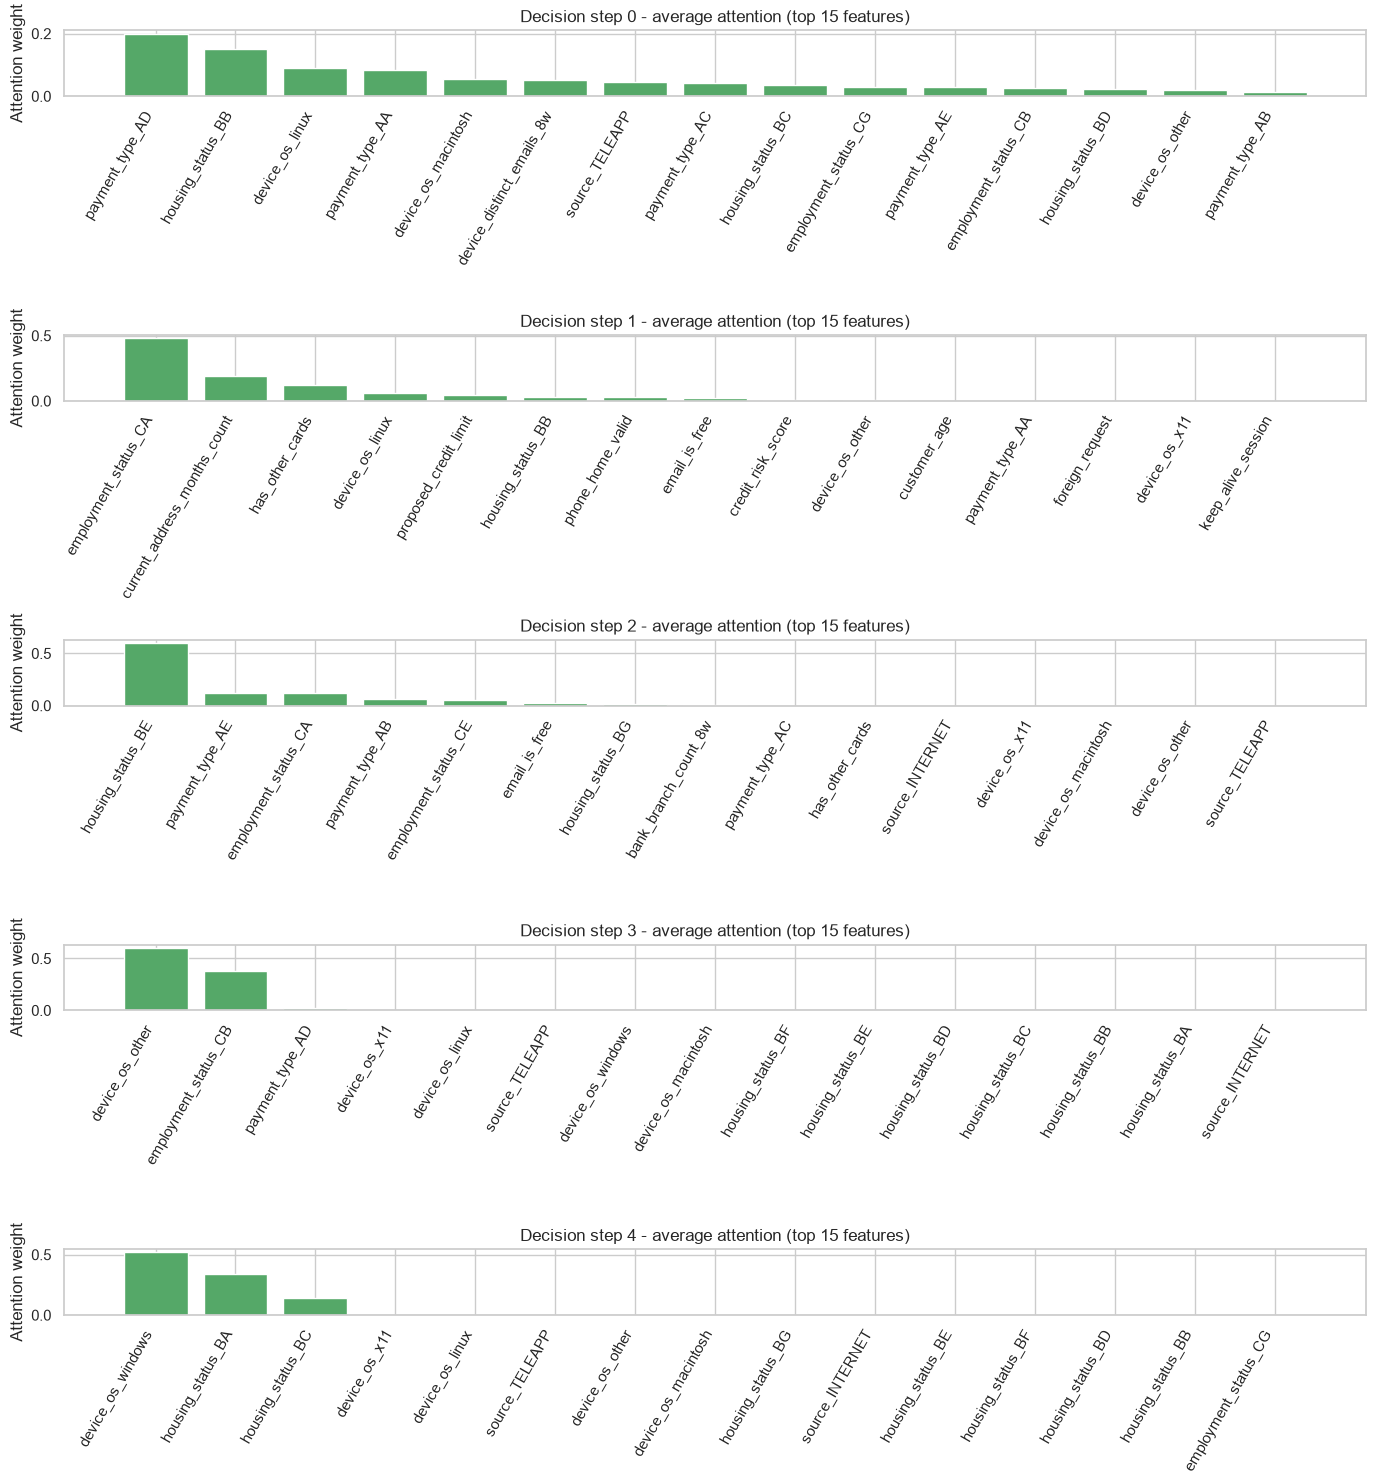

In [37]:
# Average attention mask per step, across the sampled instances -> which features
# each decision step focuses on, on average
fig, axes = plt.subplots(len(masks), 1, figsize=(14, 3 * len(masks)))
if len(masks) == 1:
    axes = [axes]

for step, mask in masks.items():
    avg_mask = mask.mean(axis=0)
    top_idx = np.argsort(avg_mask)[::-1][:15]
    axes[step].bar(range(len(top_idx)), avg_mask[top_idx], color="#55A868")
    axes[step].set_xticks(range(len(top_idx)))
    axes[step].set_xticklabels([feature_names[i] for i in top_idx], rotation=60, ha="right")
    axes[step].set_title(f"Decision step {step} - average attention (top 15 features)")
    axes[step].set_ylabel("Attention weight")

plt.tight_layout()
plt.show()

# Expected result: different steps highlighting (at least partially) different feature
# subsets, illustrating TabNet's sequential attention mechanism -- this is the property
# that makes TabNet natively interpretable, and it will be the baseline against which
# post-hoc XAI methods are compared in the next stage of the TFM.


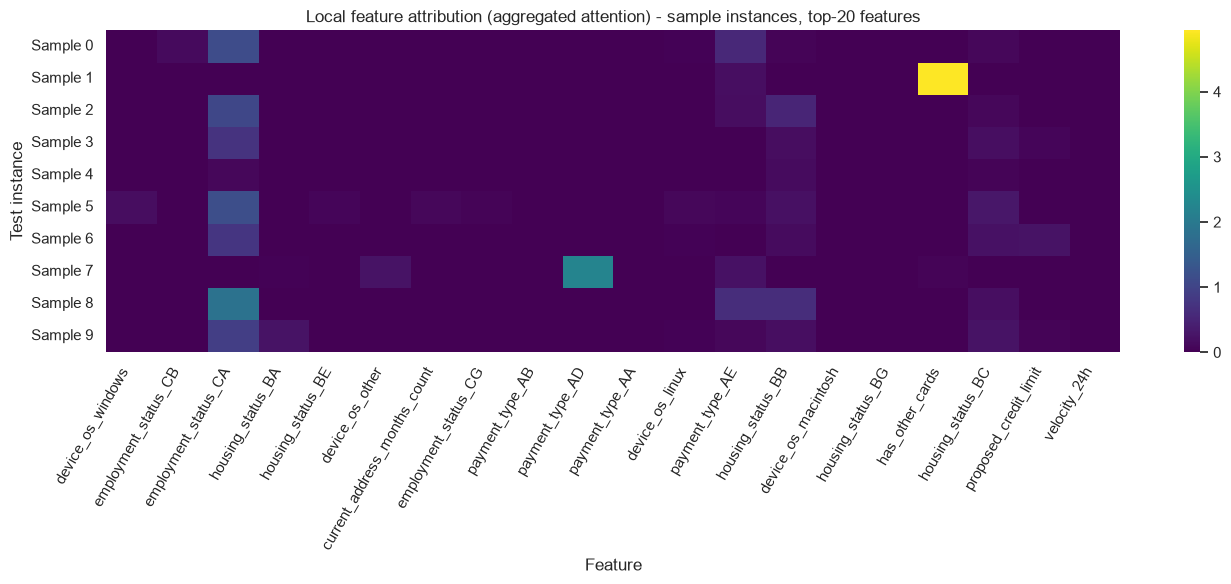

In [38]:
# Heatmap of the aggregated explanation matrix for a handful of individual instances,
# to visualize per-sample, per-feature importance (local explanations)
n_instances_to_plot = 10
top_features_idx = np.argsort(global_importances.values)[::-1][:20]
top_feature_names = [feature_names[i] for i in
                      [feature_names.index(f) for f in global_importances.head(20).index]]

instance_matrix = explain_matrix[:n_instances_to_plot][:, top_features_idx]

plt.figure(figsize=(14, 6))
sns.heatmap(instance_matrix, cmap="viridis",
            xticklabels=top_feature_names,
            yticklabels=[f"Sample {i}" for i in range(n_instances_to_plot)])
plt.title("Local feature attribution (aggregated attention) - sample instances, top-20 features")
plt.xlabel("Feature")
plt.ylabel("Test instance")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## 6. Export Model & Data for the XAI Benchmark Notebook

**Goal:** package everything the next notebook needs into a single
folder, so that notebook can simply load these artifacts instead of repeating EDA,
preprocessing and training.

What gets exported:

1. **The trained TabNet model** (`tabnet_model.zip`), via `pytorch-tabnet`'s native
   `save_model`/`load_model`.
2. **The fitted preprocessing pipeline** (`preprocessor.joblib`), so any new data is
   transformed identically to how the model was trained (median/most-frequent imputation,
   one-hot encoding, scaling).
3. **Processed train/val/test arrays** (`processed_arrays.npz`), plus the SMOTE-balanced
   training set, so metrics/explanations can be reproduced without re-running Sections 1-3.
4. **A raw (pre-preprocessing), human-readable copy of the test set** (`test_raw.csv`),
   useful for showing an analyst the *original* feature values behind a local explanation
   (e.g. a SHAP waterfall plot for "solicitud de cuenta #123").
5. **Feature name lists** (`feature_names.json`), since one-hot encoding expands the
   original ~30 columns into more numeric columns — SHAP/LIME/Captum all need this mapping
   to label their outputs correctly.
6. **A small representative background sample** (`shap_background.npy`), summarized with
   K-Means (the same idea as `shap.kmeans`), so `SHAP.KernelExplainer` — which is slow with
   large backgrounds — runs efficiently in the next notebook.
7. **A fixed, stratified subset of test instances** (`explain_subset.npz`), used
   consistently across SHAP / LIME / Integrated Gradients / TabNet-native explanations so
   that local-explanation comparisons (Section 4c-4d) are apples-to-apples, plus TabNet's
   own native explanation (`tabnet_native_explanation.npz`) for that exact subset, ready
   to compare against the post-hoc methods.
8. **Global TabNet feature importance** (`tabnet_global_importance.csv`), as the baseline
   ranking to compare global SHAP/LIME importance against.
9. **A metadata file** (`metadata.json`) recording preprocessing/split decisions
   (dropped columns, missing-value conventions, temporal split months, TabNet
   hyperparameters, random seed) for full reproducibility and for the memoria's methods
   section.

**Expected result:** a self-contained `baf_xai_export/` folder (and a zipped copy of it)
that the next notebook can load with a handful of `joblib.load` / `np.load` /
`TabNetClassifier().load_model` calls.

Note: since categorical columns were already one-hot encoded during preprocessing, the
model operates entirely in numeric space — `LimeTabularExplainer` can therefore be used in
pure continuous-feature mode (no `categorical_features` argument needed).


In [39]:
EXPORT_DIR = Path("baf_xai_export")
EXPORT_DIR.mkdir(exist_ok=True)
print("Export directory:", EXPORT_DIR.resolve())


Export directory: C:\Users\andre\Desktop\Master IA UMA\TFM\baf_xai_export


### 6.1 Save the trained TabNet model

In [40]:
clf.save_model(str(EXPORT_DIR / "tabnet_model"))
print("Saved:", EXPORT_DIR / "tabnet_model.zip")


Successfully saved model at baf_xai_export\tabnet_model.zip
Saved: baf_xai_export\tabnet_model.zip


### 6.2 Save the fitted preprocessing pipeline

In [41]:
joblib.dump(preprocessor, EXPORT_DIR / "preprocessor.joblib")
print("Saved:", EXPORT_DIR / "preprocessor.joblib")


Saved: baf_xai_export\preprocessor.joblib


### 6.3 Save processed train/val/test arrays (+ SMOTE-balanced training set)

In [42]:
np.savez_compressed(
    EXPORT_DIR / "processed_arrays.npz",
    X_train_proc=X_train_proc, y_train=y_train.values,
    X_val_proc=X_val_proc, y_val=y_val.values,
    X_test_proc=X_test_proc, y_test=y_test.values,
    X_train_res=X_train_res, y_train_res=y_train_res,
)
print("Saved:", EXPORT_DIR / "processed_arrays.npz")
print("Shapes -> X_train_proc:", X_train_proc.shape, "| X_val_proc:", X_val_proc.shape,
      "| X_test_proc:", X_test_proc.shape, "| X_train_res:", X_train_res.shape)


Saved: baf_xai_export\processed_arrays.npz
Shapes -> X_train_proc: (794989, 48) | X_val_proc: (108168, 48) | X_test_proc: (96843, 48) | X_train_res: (1573676, 48)


### 6.4 Save a raw, human-readable copy of the test set

This keeps the original (pre-imputation, pre-encoding, pre-scaling) feature values for the
test set, so local explanations can be shown next to the actual application data an analyst
would recognize (rather than scaled/encoded numbers).


In [43]:
test_raw = X_test.copy()
test_raw["fraud_bool"] = y_test.values
test_raw.to_csv(EXPORT_DIR / "test_raw.csv", index=False)
print("Saved:", EXPORT_DIR / "test_raw.csv", "-- shape:", test_raw.shape)


Saved: baf_xai_export\test_raw.csv -- shape: (96843, 29)


### 6.5 Save feature name lists

`feature_names` is the full, ordered list of column names AFTER preprocessing (numeric
features followed by one-hot encoded categorical dummies) — this is the exact order of
columns in `X_train_proc` / `X_val_proc` / `X_test_proc`, and the order SHAP/LIME/Captum
attributions will come back in.


In [44]:
with open(EXPORT_DIR / "feature_names.json", "w") as f:
    json.dump({
        "feature_names": list(feature_names),           # post-preprocessing (model input) order
        "numerical_features": list(numerical_features),  # pre-preprocessing numeric columns
        "categorical_features": list(categorical_features),  # pre-preprocessing categorical columns
    }, f, indent=2)

print("Saved:", EXPORT_DIR / "feature_names.json", "--", len(feature_names), "model-input features")


Saved: baf_xai_export\feature_names.json -- 48 model-input features


### 6.6 Build and save a SHAP background sample

`shap.KernelExplainer` (and, to a lesser extent, `GradientExplainer`) can be very slow with
a large background set. We summarize the SMOTE-balanced training data into 50 representative
points via K-Means (the same principle as `shap.kmeans`), so the next notebook can plug this
directly into `KernelExplainer(model_fn, background)` without needing to redo this step or
load the full training set.


In [45]:
N_BACKGROUND = 50
kmeans_bg = KMeans(n_clusters=N_BACKGROUND, random_state=RANDOM_STATE, n_init=10)
kmeans_bg.fit(X_train_res)
background_summary = kmeans_bg.cluster_centers_

np.save(EXPORT_DIR / "shap_background.npy", background_summary)
print("Saved:", EXPORT_DIR / "shap_background.npy", "-- shape:", background_summary.shape)


Saved: baf_xai_export\shap_background.npy -- shape: (50, 48)


### 6.7 Fix a stratified subset of test instances for local explanations

To make SHAP / LIME / Integrated Gradients / TabNet-native explanations directly comparable
in the next notebook, we freeze one fixed set of test instances now (balanced between fraud
and legitimate cases) and export it, rather than letting each XAI method sample its own
subset later.


In [46]:
N_PER_CLASS = 100  # -> 200 instances total (or fewer if the test set has less fraud than that)

y_test_arr = y_test.values
rng = np.random.RandomState(RANDOM_STATE)

fraud_idx = np.where(y_test_arr == 1)[0]
legit_idx = np.where(y_test_arr == 0)[0]

n_fraud = min(N_PER_CLASS, len(fraud_idx))
n_legit = min(N_PER_CLASS, len(legit_idx))

explain_idx = np.concatenate([
    rng.choice(fraud_idx, size=n_fraud, replace=False),
    rng.choice(legit_idx, size=n_legit, replace=False),
])
rng.shuffle(explain_idx)

X_explain_proc = X_test_proc[explain_idx]
y_explain = y_test_arr[explain_idx]

np.savez_compressed(
    EXPORT_DIR / "explain_subset.npz",
    indices=explain_idx,
    X_explain_proc=X_explain_proc,
    y_explain=y_explain,
)
print("Saved:", EXPORT_DIR / "explain_subset.npz", "-- instances:", X_explain_proc.shape[0],
      f"({n_fraud} fraud, {n_legit} legit)")


Saved: baf_xai_export\explain_subset.npz -- instances: 200 (100 fraud, 100 legit)


### 6.8 Save TabNet's native explanation for that exact subset

Computed once here and exported, so the XAI benchmark notebook can directly compare
post-hoc methods against this native baseline without needing to reload the model just for
this (though it could, since the model is also exported).


In [47]:
native_explain_matrix, native_masks = clf.explain(X_explain_proc)

masks_dict_to_save = {f"mask_step_{step}": mask for step, mask in native_masks.items()}
np.savez_compressed(
    EXPORT_DIR / "tabnet_native_explanation.npz",
    explain_matrix=native_explain_matrix,
    n_steps=len(native_masks),
    **masks_dict_to_save,
)
print("Saved:", EXPORT_DIR / "tabnet_native_explanation.npz",
      "-- explain_matrix shape:", native_explain_matrix.shape, "| steps:", len(native_masks))


Saved: baf_xai_export\tabnet_native_explanation.npz -- explain_matrix shape: (200, 48) | steps: 5


### 6.9 Save the global TabNet feature importance (baseline ranking)

In [48]:
global_importances.to_csv(EXPORT_DIR / "tabnet_global_importance.csv", header=["importance"])
print("Saved:", EXPORT_DIR / "tabnet_global_importance.csv")


Saved: baf_xai_export\tabnet_global_importance.csv


### 6.10 Save metadata for reproducibility

In [49]:
metadata = {
    "random_state": RANDOM_STATE,
    "target": TARGET,
    "split_strategy": "temporal",
    "train_months": train_months,
    "val_month": val_month,
    "test_month": test_month,
    "sentinel_missing_cols": sentinel_missing_cols,   # exact -1 == missing
    "negative_missing_cols": negative_missing_cols,   # any negative value == missing
    "dropped_columns": cols_to_drop,
    "class_weight_dict": class_weight_dict,
    "tabnet_params": {
        "n_d": tabnet_params["n_d"],
        "n_a": tabnet_params["n_a"],
        "n_steps": tabnet_params["n_steps"],
        "gamma": tabnet_params["gamma"],
        "lambda_sparse": tabnet_params["lambda_sparse"],
        "mask_type": tabnet_params["mask_type"],
    },
    "test_metrics": {
        "auc_roc": float(auc),
        "recall": float(recall),
        "precision": float(precision),
        "f1": float(f1),
        "fpr": float(fpr),
    },
    "n_features_after_preprocessing": len(feature_names),
}

with open(EXPORT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", EXPORT_DIR / "metadata.json")


Saved: baf_xai_export\metadata.json


### 6.11 Zip everything for easy download / transfer

In [50]:
import shutil

zip_path = shutil.make_archive("baf_xai_export", "zip", root_dir=".", base_dir=str(EXPORT_DIR))
print("Created archive:", zip_path)

print("\nContents of", EXPORT_DIR, ":")
for f in sorted(EXPORT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:35s} {size_kb:10.1f} KB")


Created archive: c:\Users\andre\Desktop\Master IA UMA\TFM\baf_xai_export.zip

Contents of baf_xai_export :
  explain_subset.npz                        19.0 KB
  feature_names.json                         2.0 KB
  metadata.json                              1.0 KB
  preprocessor.joblib                        6.3 KB
  processed_arrays.npz                  256845.2 KB
  shap_background.npy                       18.9 KB
  tabnet_global_importance.csv               1.9 KB
  tabnet_model.zip                         161.9 KB
  tabnet_native_explanation.npz             45.3 KB
  test_raw.csv                           18402.1 KB


## 7. Summary

- **EDA** confirmed a strongly imbalanced target and the presence of encoded missing
  values across several columns, also we discovered the need to remove certain columns for high null presence or for having a single value.
- **Preprocessing** removed columns, applied median/most-frequent imputation, one-hot encoding, standard
  scaling, and SMOTE oversampling on the training data only, keeping validation/test
  realistic.
- **TabNet** was trained with `n_steps=5`, `n_d=n_a=16`, using early stopping on validation
  AUC.
- **Evaluation** reported AUC-ROC, Recall (TPR), FPR, F1 and the confusion matrix on the
  untouched test set, plus Recall at fixed FPR budgets - the operating points most relevant
  in a real fraud-detection setting.
- **Native feature importance** was extracted both globally (`feature_importances_`) and
  per decision step (`explain()` / attention masks), establishing a first interpretability
  baseline.

**Next steps (subsequent notebook, per the anteproyecto):** apply post-hoc XAI methods
(SHAP, LIME, Integrated Gradients via Captum) on this trained model, and evaluate them
quantitatively with Quantus/OpenXAI (fidelity, robustness, stability), comparing them
against this native TabNet explanation. Section 6 exports everything needed to do
that in a separate notebook, without having to retrain anything.
